# Geometric Canaries — streaming CoT checkpoint / rollback

**Question.** If we segment a proof attempt into reasoning steps, can we (a) catch faulty
logic at the step where it appears and (b) make proving *cheaper* by rolling back to the
last safe checkpoint instead of resampling from scratch?

**Model.** `deepseek-ai/DeepSeek-Prover-V2-7B`, 4-bit, single Colab GPU.
Set `DRY_RUN = True` to smoke-test the pipeline with a tiny model first.

**What changed vs. the previous notebook**

| before | now | why |
|---|---|---|
| generate 512 tokens → segment → detect → roll back | detect **online** at each segment boundary during generation | tokens after the first bad segment are never generated |
| rollback re-encodes the whole prefix every round | checkpoint = **KV-cache length**; rollback = `cache.crop()` | prompt + good prefix are computed exactly once |
| no compute-matched baseline | `restart` mode: same detector, but resample from scratch | isolates the speed contribution of checkpointing itself |
| 6 mutation pairs + 4 real-bug pairs + prove-or-refute | 3 mutation pairs, regex outcome proxy | methodology first; scale the dataset back up once the loop is trusted |

The three run modes share one code path (`prove(mode=...)`), so every comparison is
apples-to-apples: same sampler, same seeds, same detector.


In [ ]:
# --- Setup -------------------------------------------------------------
# Safe default: use the small CPU-capable model. Set
# GEOMETRIC_CANARIES_DRY_RUN=0 only in a GPU environment with the optional
# `gpu` dependency group installed.
import os

PROJECT_CACHE = os.path.join(os.getcwd(), ".cache")
os.environ.setdefault("HF_HOME", os.path.join(PROJECT_CACHE, "huggingface"))
os.environ.setdefault("MPLCONFIGDIR", os.path.join(PROJECT_CACHE, "matplotlib"))

DRY_RUN = os.environ.get("GEOMETRIC_CANARIES_DRY_RUN", "1") != "0"
DEVICE_REQUEST = os.environ.get("GEOMETRIC_CANARIES_DEVICE", "auto").lower()
if DEVICE_REQUEST not in {"auto", "cpu", "cuda"}:
    raise ValueError("GEOMETRIC_CANARIES_DEVICE must be one of: auto, cpu, cuda")

import torch

CUDA_AVAILABLE = torch.cuda.is_available()
if DEVICE_REQUEST == "cuda" and not CUDA_AVAILABLE:
    raise RuntimeError(
        "CUDA was requested but is unavailable. Check nvidia-smi and the "
        "installed PyTorch CUDA build."
    )
DEVICE_MAP = (
    "cuda"
    if DEVICE_REQUEST == "cuda"
    else ("auto" if DEVICE_REQUEST == "auto" and CUDA_AVAILABLE else "cpu")
)
USE_CUDA = DEVICE_MAP != "cpu"
MODEL_DTYPE = (
    torch.bfloat16
    if USE_CUDA and torch.cuda.is_bf16_supported()
    else (torch.float16 if USE_CUDA else torch.float32)
)
print(f"CUDA: {CUDA_AVAILABLE}; device: {DEVICE_MAP}; dtype: {MODEL_DTYPE}")
if CUDA_AVAILABLE:
    p = torch.cuda.get_device_properties(0)
    print(f"GPU: {p.name}, {p.total_memory / 1e9:.1f} GB")
elif not DRY_RUN:
    print("!! no GPU — set DRY_RUN = True or switch runtime")

In [ ]:
# --- Model -------------------------------------------------------------
from transformers import AutoModelForCausalLM, AutoTokenizer

# small testing model (0.5 B parameters) w/ 32 bit
# for quick pipeline testing
if DRY_RUN:
    MODEL_ID = "Qwen/Qwen2.5-0.5B-Instruct"
    model = AutoModelForCausalLM.from_pretrained(
        MODEL_ID, dtype=MODEL_DTYPE, device_map=DEVICE_MAP
    )
# larger model (7 B) w/ 4 (16) bit quantization for storage (calculation) in GPU
# for precision
else:
    from transformers import BitsAndBytesConfig

    MODEL_ID = "deepseek-ai/DeepSeek-Prover-V2-7B"
    bnb = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_compute_dtype=MODEL_DTYPE,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_use_double_quant=True,
    )
    model = AutoModelForCausalLM.from_pretrained(
        MODEL_ID, quantization_config=bnb, device_map=DEVICE_MAP, dtype=MODEL_DTYPE
    )
model.eval()
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)

# Use the end-of-sequence token for padding if no padding token is defined
if tokenizer.pad_token_id is None:
    tokenizer.pad_token = tokenizer.eos_token

# Use a layer around two-thirds (i.e. 0.65) depth to contain developed
# reasoning information before it is converted into the final output
N_LAYERS = model.config.num_hidden_layers
CAPTURE_LAYER = int(N_LAYERS * 0.65)  # residual stream, ~2/3 depth


def encode_prompt(prompt):
    """Chat-template the prompt (DSP-V2 is a chat model); fall back to raw."""
    # wrap in the model’s chat format and then converts that entire formatted text into numerical token IDs
    try:
        out = tokenizer.apply_chat_template(
            [{"role": "user", "content": prompt}],
            add_generation_prompt=True,
            return_tensors="pt",
        )
        return (
            out["input_ids"]
            if isinstance(out, dict)
            else (out.input_ids if hasattr(out, "input_ids") else out)
        )
    # converts only the exact raw text
    except Exception:
        return tokenizer(prompt, return_tensors="pt").input_ids


print(f"{MODEL_ID}: {N_LAYERS} layers, capturing layer {CAPTURE_LAYER}")

## Dataset — 3 Aeneas-style minimal pairs

Each item is a (fixed, buggy) pair in the Aeneas-faithful Lean subset (`Result` monad,
fallible machine-integer ops) with a spec that is provable for the fixed variant and
false for the buggy one. Three bug families kept for the prototype: loop progress
(`binary_search`), underflow panic (`sat_sub`), flipped comparison (`clamp`). The full
mutation + real-advisory dataset from the previous notebook drops back in unchanged once
the loop is trusted — `prove()` only needs `build_prompt(item, variant)`.

In [3]:
LEAN_PREAMBLE = """\
/- Minimal self-contained stand-in for the Aeneas Lean support library. -/
inductive Result (\u03b1 : Type) where
  | ok (v : \u03b1)
  | fail
deriving Repr, DecidableEq

instance : Monad Result where
  pure := Result.ok
  bind x f := match x with | .ok v => f v | .fail => .fail

abbrev U32.max : Nat := 4294967295

/-- Machine-integer ops are fallible, as in the Aeneas translation:
    overflow/underflow surfaces as `.fail` (a Rust panic). -/
def U32.add (a b : Nat) : Result Nat :=
  if a + b \u2264 U32.max then .ok (a + b) else .fail

def U32.sub (a b : Nat) : Result Nat :=
  if b \u2264 a then .ok (a - b) else .fail

def U32.mul (a b : Nat) : Result Nat :=
  if a * b \u2264 U32.max then .ok (a * b) else .fail

/-- Fallible indexing: out-of-bounds is a panic (`.fail`). -/
def List.index (l : List \u03b1) (i : Nat) : Result \u03b1 :=
  match l.get? i with
  | some v => .ok v
  | none => .fail
"""


def rust_comment(name):
    return f"-- Aeneas-style translation of Rust `{name}`\n"


LEAN_MODELS = {
    "binary_search": {
        "bug_type": "progress_bug",
        "real_world_analogue": "loop-progress / midpoint bug family "
        "(cf. the JDK Arrays.binarySearch overflow, Bloch 2006)",
        "fixed_defn": rust_comment("binary_search")
        + """\
def binary_search_loop (v : List Nat) (x lo hi fuel : Nat) :
    Result (Option Nat) :=
  match fuel with
  | 0 => .fail
  | Nat.succ fuel =>
    if lo < hi then do
      let mid := lo + (hi - lo) / 2
      let vm \u2190 v.index mid
      if vm = x then .ok (some mid)
      else if vm < x then binary_search_loop v x (mid + 1) hi fuel
      else binary_search_loop v x lo mid fuel
    else .ok none

def binary_search (v : List Nat) (x : Nat) : Result (Option Nat) :=
  binary_search_loop v x 0 v.length (v.length + 1)""",
        "buggy_defn": rust_comment("binary_search")
        + """\
def binary_search_loop (v : List Nat) (x lo hi fuel : Nat) :
    Result (Option Nat) :=
  match fuel with
  | 0 => .fail
  | Nat.succ fuel =>
    if lo < hi then do
      let mid := lo + (hi - lo) / 2
      let vm \u2190 v.index mid
      if vm = x then .ok (some mid)
      else if vm < x then binary_search_loop v x mid hi fuel
      else binary_search_loop v x lo mid fuel
    else .ok none

def binary_search (v : List Nat) (x : Nat) : Result (Option Nat) :=
  binary_search_loop v x 0 v.length (v.length + 1)""",
        "spec": """\
theorem binary_search_total (v : List Nat) (x : Nat) :
    \u2203 r, binary_search v x = .ok r := by sorry""",
    },
    "sat_sub": {
        "bug_type": "underflow_panic",
        "real_world_analogue": "integer-underflow panic class "
        "(recurring RustSec advisory category)",
        "fixed_defn": rust_comment("sat_sub")
        + """\
def satSub (a b : Nat) : Result Nat :=
  if a \u2265 b then U32.sub a b else .ok 0""",
        "buggy_defn": rust_comment("sat_sub")
        + """\
def satSub (a b : Nat) : Result Nat :=
  U32.sub a b""",
        "spec": """\
theorem satSub_total (a b : Nat) : \u2203 v, satSub a b = .ok v := by sorry""",
    },
    "clamp": {
        "bug_type": "flipped_comparison",
        "real_world_analogue": "comparison-flip logic-error family",
        "fixed_defn": rust_comment("clamp")
        + """\
def clamp (lo hi x : Nat) : Nat :=
  if x < lo then lo else if x > hi then hi else x""",
        "buggy_defn": rust_comment("clamp")
        + """\
def clamp (lo hi x : Nat) : Nat :=
  if x < lo then lo else if x \u2265 hi then x else x""",
        "spec": """\
theorem clamp_le (lo hi x : Nat) (h : lo \u2264 hi) :
    clamp lo hi x \u2264 hi := by sorry""",
    },
}

MINIMAL_PAIRS = []
for name, m in LEAN_MODELS.items():
    MINIMAL_PAIRS.append(
        {
            "id": name,
            "bug_type": m["bug_type"],
            "provenance": "mutation",
            "real_world_analogue": m["real_world_analogue"],
            "fixed": {"defn": m["fixed_defn"], "spec": m["spec"], "provable": True},
            "buggy": {"defn": m["buggy_defn"], "spec": m["spec"], "provable": False},
        }
    )

# DeepSeek-Prover-V2 CoT prompt format: "Complete the following Lean 4 code" with a
# proof-plan instruction, matching the model's training distribution. The Mathlib
# header matches the distribution too; our preamble is self-contained, so offline
# checking can drop the import if you verify without Mathlib.
DSP_HEADER = "import Mathlib\nimport Aesop\n\nset_option maxHeartbeats 400000\n\n"


def build_prompt(item, variant, use_mathlib_header=True):
    v = item[variant]
    code_block = (
        (DSP_HEADER if use_mathlib_header else "")
        + LEAN_PREAMBLE
        + "\n"
        + v["defn"]
        + "\n\n"
        + v["spec"]
    )
    return (
        "Complete the following Lean 4 code:\n\n```lean4\n" + code_block + "\n```\n\n"
        "Before producing the Lean 4 code to formally prove the given theorem, "
        "provide a detailed proof plan outlining the main proof steps and "
        "strategies.\n"
        "The plan should highlight key ideas, intermediate lemmas, and proof "
        "structures that will guide the construction of the final formal proof. "
        "If the statement is false, state this explicitly and give a concrete "
        "counterexample instead of a proof."
    )


pair_ids: list[str] = []
for pair in MINIMAL_PAIRS:
    pair_id = pair["id"]
    assert isinstance(pair_id, str)
    pair_ids.append(pair_id)

print(f"{len(MINIMAL_PAIRS)} minimal pairs: " + ", ".join(pair_ids))

3 minimal pairs: binary_search, sat_sub, clamp


## Segmentation and the bad-logic detector

A **segment** is a candidate reasoning step; boundaries are blank lines, enumerators,
discourse markers, and code fences. Detection is **causal and online**: the moment a
segment closes, it is scored against the running statistics of the segments before it —

- `z_ent` — segment mean next-token entropy vs. prior segments (the model is flailing)
- `z_drift` — cosine distance of the segment's hidden-state centroid from the running
  centroid of the accepted prefix (the geometric-canary signal)
- `smell` — lexical proof-smells (`sorry`, `obviously`, `it is easy to see`, …)

`score = 0.5·z_ent + 0.5·z_drift + 1.5·smell`, flag when `score > thresh`.

In [4]:
import re
import time

import numpy as np
import torch
import torch.nn.functional as F
from transformers import DynamicCache

# Handle both standard newlines and byte-level BPE newlines ('Ċ')
BOUNDARY_PAT = re.compile(
    r"[\nĊ]\s*[\nĊ]"
    r"|[\nĊ](?=Step \d)"
    r"|[\nĊ](?=\d+[\.)]\s)"
    r"|[\nĊ](?=```)"
    r"|[\nĊ](?=(?:First|Second|Next|Then|Now|Finally|Therefore|Thus)[,\s])"
    r"|[\nĊ](?=\s*<;>)",
    flags=re.IGNORECASE,
)
# prevents extremely short segments
MIN_SEG_TOKENS = 8

# define smells: sorry, admit, ...
LEXICAL_SMELLS = re.compile(
    r"\bsorry\b|\badmit\b|native_decide|\bobviously\b|\btrivially\b"
    r"|clearly\s+true|it is easy to see",
    re.IGNORECASE,
)


# After every token, the code asks whether a segment boundary has appeared
def find_boundary(text, from_char):
    m = BOUNDARY_PAT.search(text, from_char)
    if m:
        return m.end()

    nl1 = text.find("\n", from_char + 100)
    nl2 = text.find("Ċ", from_char + 100)
    nls = [n for n in (nl1, nl2) if n != -1]
    return min(nls) + 1 if nls else None


def cosine_dist(a, b):
    na, nb = np.linalg.norm(a), np.linalg.norm(b)
    return 0.0 if na == 0 or nb == 0 else 1.0 - float(a @ b) / (na * nb)


"""
history contains the previously closed segments that the system has kept
e.g. for segment 4 -> history from segment 1-3
formula for score: 0.5 zent \u200b+ 0.5zdrift \u200b+ 1.5(smell)

measure:
z_ent: Model’s next-token probabilities -> Was the model unusually uncertain while writing this segment?
  -> def: z_ent is (current segment entropy - previous mean entropy) / preious entropy variation
z_drift: Model’s hidden-state geometry -> Is the current segment farther from the earlier reasoning than segments normally are?
  ->
smell: Actual generated words -> Did the model use a known suspicious shortcut phrase or invalid Lean construct?
"""


def score_segment(seg, history, warmup=0):
    smell_score = 1.5 if seg["smell"] else 0.0
    if len(history) <= warmup:
        return smell_score + 0.1  # Allow smells to trigger even during warmup

    ents = np.array([h["mean_entropy"] for h in history])
    z_ent = (seg["mean_entropy"] - ents.mean()) / max(float(ents.std()), 0.25)
    cents = [h["centroid"] for h in history if h["centroid"] is not None]
    if seg["centroid"] is not None and cents:
        run = np.mean(cents, axis=0)
        drifts = np.array([cosine_dist(c, run) for c in cents])
        d = cosine_dist(seg["centroid"], run)
        z_drift = (
            (d - drifts.mean()) / max(float(drifts.std()), 0.05)
            if len(drifts) > 1
            else 0.0
        )
    else:
        z_drift = 0.0
    return 0.5 * z_ent + 0.5 * z_drift + smell_score

## The `prove()` loop — checkpoint = KV-cache length

One manual decode loop drives all three conditions:

- **`plain`** — generate once, no intervention (baseline)
- **`rollback`** — on a flag, `cache.crop(checkpoint)`: the KV cache is truncated to the
  start of the flagged segment, an optional corrective hint is appended, and sampling
  continues. *The prompt and the good prefix are never recomputed* — a rollback costs
  only the hint tokens.
- **`restart`** — on a flag, throw everything away and re-prefill from the prompt
  (same detector, no checkpointing). This is the compute-matched control that isolates
  what checkpointing itself buys.

`n_forward` counts every token position pushed through the model (prefills + decode +
hints), which is the honest compute cost; abandoned branches are kept as counterfactual
data for the geometry analysis.

In [5]:
HINT = (
    "\nWait -- let me re-check the last step carefully before continuing. "
    "I should verify each claim against the definitions.\n"
)


def _sample(logits, temperature, top_p, gen):
    # selects the token with the highest logit if temperature is zero or negative
    if temperature <= 0:
        return int(logits.argmax())

    # convert logits into probabilities
    probs = F.softmax(logits / temperature, dim=-1)
    sp, si = probs.sort(descending=True)
    # keep the top-p candidate set
    keep = (sp.cumsum(-1) - sp) <= top_p
    keep[0] = True
    sp = sp * keep
    idx = torch.multinomial(sp / sp.sum(), 1, generator=gen)
    return int(si[idx])


@torch.no_grad()
def prove(
    prompt,
    mode="rollback",
    max_new_tokens=512,
    max_rollbacks=3,
    thresh=1.8,
    temperature=1.0,
    top_p=0.95,
    seed=0,
    inject_hint=True,
    verbose=False,
):
    """One streaming generate-detect-rollback run.

    mode:
      'plain'    -- generate once, detect nothing
      'rollback' -- on a flagged segment, crop the KV cache back to the
                    checkpoint at the segment start and resample from there
      'restart'  -- on a flagged segment, throw everything away and resample
                    from the prompt (matched-intervention baseline: same
                    detector, no checkpointing)

    A *checkpoint* is just a sequence length: the KV cache up to the start of
    the current segment.  Rollback = cache.crop(ck) -- the prompt and the good
    prefix are never recomputed.

    Returns dict with text, per-token signals, segments, events, forward-pass
    and wall-time accounting, and abandoned branches (counterfactual data).

    procedures summary:
    Model generates tokens
    → code detects a boundary
    → segment is “closed”
    → its statistics are calculated
    → it is scored
    → accepted or rolled back
    → next segment begins
    """
    t0 = time.time()
    gen = torch.Generator(device="cpu").manual_seed(seed)
    input_ids = encode_prompt(prompt).to(model.device)
    prompt_len = input_ids.shape[1]

    # stores those key/value vectors as new tokens are generated (dynamic)
    cache = DynamicCache()
    out = model(
        input_ids=input_ids,
        past_key_values=cache,
        use_cache=True,
        output_hidden_states=True,
    )
    logits = out.logits[0, -1].float()
    n_forward = prompt_len  # prefill counts once; rollback never repeats it

    """
    prefill: counts how many times the whole original prompt has been processed
    generation: one new token per model call
      in rollback mode, it remains 1, because cropping preserves the cached prompt
      in restart mode, the cache is thrown away and the prompt is processed again:
    """
    n_prefills = 1

    # live state (generation-relative)
    ids, text = [], ""
    entropy, logprob, hidden = [], [], []

    # mark where the current unfinished segment begins in ids (seg_start_tok) and text (seg_start_char)
    seg_start_tok, seg_start_char = 0, 0

    # where to resume searching for a future boundary
    probe_char = 0  # search cursor: skips rejected (too-short) boundaries
    history, segments, events, abandoned = [], [], [], []
    rollbacks = 0

    # decides that the current reasoning step has ended, so it packages and scores it
    def close_segment(end_tok, end_char):
        sl = slice(seg_start_tok, end_tok)
        h = np.stack(hidden[sl]) if hidden[sl] else None
        seg = {
            "idx": len(segments),
            "tok_start": seg_start_tok,
            "tok_end": end_tok,
            "text": text[seg_start_char:end_char],
            "mean_entropy": float(np.nanmean(entropy[sl])),
            "min_logprob": float(np.nanmin(logprob[sl])),
            "centroid": h.mean(axis=0) if h is not None else None,
            "smell": bool(LEXICAL_SMELLS.search(text[seg_start_char:end_char])),
        }
        seg["score"] = score_segment(seg, history)
        return seg

    step = 0
    while step < max_new_tokens:
        tok = _sample(logits.cpu(), temperature, top_p, gen)
        h = out.hidden_states[CAPTURE_LAYER][0, -1].float().cpu().numpy()
        logps = F.log_softmax(logits, dim=-1)
        entropy.append(float(-(logps.exp() * logps).sum()))
        logprob.append(float(logps[tok]))
        hidden.append(h)
        ids.append(tok)
        text += tokenizer.decode([tok])
        step += 1

        if tok == tokenizer.eos_token_id:
            break

        # --- online boundary check --------------------------------------
        b = find_boundary(text, probe_char)
        if b is not None:
            # map char boundary -> token index
            # char->token map: walk per-token decodes (consistent with `text`)
            pos, end_tok = 0, len(ids)
            for i, tid in enumerate(ids):
                pos += len(tokenizer.decode([tid]))
                if pos >= b:
                    end_tok = i + 1
                    break
            if end_tok - seg_start_tok < MIN_SEG_TOKENS:
                probe_char = b  # too short: merge onwards, keep searching
            else:
                seg = close_segment(end_tok, b)
                segments.append(seg)
                flagged = seg["score"] > thresh
                if verbose:
                    print(
                        f"  seg {seg['idx']:2d} tok {seg['tok_start']:4d}-"
                        f"{seg['tok_end']:4d} score {seg['score']:+.2f}"
                        f"{'  << FLAG' if flagged else ''}"
                    )
                if flagged and mode != "plain" and rollbacks < max_rollbacks:
                    rollbacks += 1
                    abandoned.append(
                        {
                            "at_segment": seg["idx"],
                            "text": text,
                            "ids": list(ids),
                            "entropy": list(entropy),
                            "logprob": list(logprob),
                        }
                    )
                    if mode == "rollback":
                        ck = prompt_len + seg["tok_start"]
                        # before cropping: [prompt][good prefix][flagged segment]
                        # after cropping: [prompt][good prefix]
                        cache.crop(ck)

                        # delete the flagged segment from the other stored data
                        del ids[seg["tok_start"] :]
                        del entropy[seg["tok_start"] :]
                        del logprob[seg["tok_start"] :]
                        del hidden[seg["tok_start"] :]
                        text = text[:seg_start_char]
                        segments.pop()  # the bad segment is gone
                        events.append(
                            {
                                "type": "rollback",
                                "to_tok": seg["tok_start"],
                                "score": seg["score"],
                            }
                        )
                        cont_ids = []
                        if inject_hint:
                            cont_ids = tokenizer(HINT, add_special_tokens=False)[
                                "input_ids"
                            ]
                        if cont_ids:
                            ct = torch.tensor([cont_ids], device=model.device)
                            out = model(
                                input_ids=ct,
                                past_key_values=cache,
                                use_cache=True,
                                output_hidden_states=True,
                            )
                            n_forward += len(cont_ids)
                            for htok in cont_ids:
                                ids.append(htok)
                                text += tokenizer.decode([htok])
                                entropy.append(np.nan)
                                logprob.append(np.nan)
                                hidden.append(
                                    out.hidden_states[CAPTURE_LAYER][0, -1]
                                    .float()
                                    .cpu()
                                    .numpy()
                                )
                            seg_start_tok, seg_start_char = len(ids), len(text)
                            probe_char = len(text)
                            logits = out.logits[0, -1].float()
                            step = len(ids)
                            continue
                        else:
                            # need fresh logits at the checkpoint: cheapest is to
                            # re-run the last checkpoint token -- crop one extra
                            cache.crop(ck - 1)
                            last = torch.tensor(
                                [[input_ids[0, -1] if not ids else ids[-1]]],
                                device=model.device,
                            )
                            out = model(
                                input_ids=last,
                                past_key_values=cache,
                                use_cache=True,
                                output_hidden_states=True,
                            )
                            n_forward += 1
                            seg_start_tok, seg_start_char = len(ids), len(text)
                            probe_char = len(text)
                            logits = out.logits[0, -1].float()
                            step = len(ids)
                            continue
                    else:  # restart baseline: full re-prefill
                        cache = DynamicCache()
                        out = model(
                            input_ids=input_ids,
                            past_key_values=cache,
                            use_cache=True,
                            output_hidden_states=True,
                        )
                        n_forward += prompt_len
                        n_prefills += 1
                        logits = out.logits[0, -1].float()
                        ids, text = [], ""
                        entropy, logprob, hidden = [], [], []
                        seg_start_tok, seg_start_char, probe_char = 0, 0, 0
                        history, segments = [], []
                        events.append({"type": "restart", "score": seg["score"]})
                        step = 0
                        continue
                history.append(seg)
                seg_start_tok, seg_start_char = seg["tok_end"], b
                probe_char = b

        # --- ordinary decode step ---------------------------------------
        nt = torch.tensor([[tok]], device=model.device)
        out = model(
            input_ids=nt,
            past_key_values=cache,
            use_cache=True,
            output_hidden_states=True,
        )
        logits = out.logits[0, -1].float()
        n_forward += 1

    # close the trailing segment for bookkeeping
    if len(ids) - seg_start_tok > 0:
        seg = close_segment(len(ids), len(text))
        segments.append(seg)

    return {
        "mode": mode,
        "text": text,
        "ids": ids,
        "entropy": np.array(entropy),
        "logprob": np.array(logprob),
        "hidden": np.stack(hidden) if hidden else np.zeros((0, 1)),
        "segments": segments,
        "events": events,
        "abandoned": abandoned,
        "rollbacks": rollbacks,
        "n_forward": n_forward,
        "n_prefills": n_prefills,
        "gen_tokens": len(ids) + sum(len(a["ids"]) for a in abandoned),
        "wall_s": time.time() - t0,
    }


CLAIM_PROOF = re.compile(r"```lean4?[\s\S]*?```|\bQED\b", re.IGNORECASE)
CLAIM_FALSE = re.compile(
    r"counterexample|statement is false|does not hold"
    r"|cannot be proved",
    re.IGNORECASE,
)


def proxy_outcome(text):
    """Stub outcome until Lean verification is wired in."""
    if CLAIM_FALSE.search(text):
        return "claims_false"
    if CLAIM_PROOF.search(text):
        return "claims_proof"
    return "no_conclusion"

In [6]:
# --- Demo: one buggy item, watch the loop work --------------------------
item = MINIMAL_PAIRS[0]
res = prove(
    build_prompt(item, "buggy"),
    mode="rollback",
    max_new_tokens=512,
    thresh=1.8,
    seed=0,
    verbose=True,
)

print(
    f"\nmode={res['mode']}  rollbacks={res['rollbacks']}  "
    f"segments={len(res['segments'])}"
)
print(
    f"forward passes: {res['n_forward']}  (prefills: {res['n_prefills']})  "
    f"wall: {res['wall_s']:.1f}s"
)
for e in res["events"]:
    print("  event:", e)
print("\noutcome:", proxy_outcome(res["text"]))
print("\n--- final text (tail) ---\n", res["text"][-800:])

  seg  0 tok    0-  32 score +0.10
  seg  1 tok   32-  62 score -1.35
  seg  2 tok   62- 100 score +0.03
  seg  3 tok  100- 147 score -0.12

mode=rollback  rollbacks=0  segments=5
forward passes: 732  (prefills: 1)  wall: 55.1s

outcome: no_conclusion

--- final text (tail) ---
 ###ĠDetailedĠProofĠandĠPlanĊ<｜begin of sentence｜>classĠGraph(vertices:ĠSet[Int])Ġ{ĊĠĠdefĠneighbors(vertex:ĠInt):ĠSet[Int]Ġ=ĊĠĠĠĠverticesĠmatchĠ{ĊĠĠĠĠĠĠcaseĠvĠifĠvertexĠ<Ġ0Ġ=>ĠSet.emptyĊĠĠĠĠĠĠcaseĠ_Ġ=>ĠvĊĠĠĠĠ}Ċ}ĊĊclassĠTestGraphĠextendsĠGraph(Set(0,Ġ1,Ġ2))Ġ{ĊĠĠoverrideĠdefĠneighbors(vertex:ĠInt):ĠSet[Int]Ġ=ĊĠĠĠĠvertexĠmatchĠ{ĊĠĠĠĠĠĠcaseĠ0Ġ=>ĠSet(1,Ġ2)ĊĠĠĠĠĠĠcaseĠ1Ġ=>ĠSet(0,Ġ2)ĊĠĠĠĠĠĠcaseĠ2Ġ=>ĠSet(0,Ġ1)ĊĠĠĠĠĠĠcaseĠ_Ġ=>ĠSet.emptyĊĠĠĠĠ}Ċ}Ċ<｜end of sentence｜>


## Visualization — signal timeline with rollback markers

Entropy (top) and chosen-token logprob (bottom) over the *live* trace. Segment
boundaries are vertical lines, flagged-then-rolled-back positions are red markers, and
hint injections show as gaps (hint tokens are forced, so they carry no sampling
entropy).

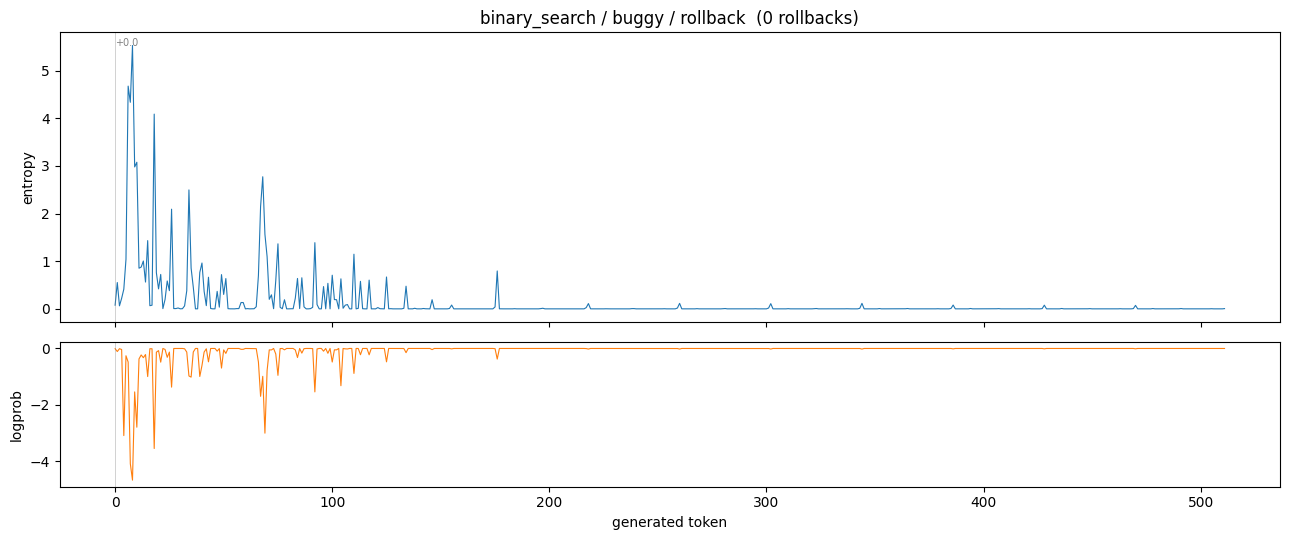

In [ ]:
import matplotlib.pyplot as plt


def plot_timeline(res, title="CoT signal timeline"):
    _, axes = plt.subplots(
        2, 1, figsize=(13, 5.5), sharex=True, gridspec_kw={"height_ratios": [2, 1]}
    )
    x = np.arange(len(res["entropy"]))
    axes[0].plot(x, res["entropy"], lw=0.8)
    axes[0].set_ylabel("entropy")
    axes[1].plot(x, res["logprob"], lw=0.8, color="tab:orange")
    axes[1].set_ylabel("logprob")
    axes[1].set_xlabel("generated token")
    for s in res["segments"]:
        for ax in axes:
            ax.axvline(s["tok_start"], color="gray", lw=0.5, alpha=0.5)
        axes[0].text(
            s["tok_start"],
            axes[0].get_ylim()[1] * 0.95,
            f"{s['score']:+.1f}",
            fontsize=7,
            color="gray",
        )
    for e in res["events"]:
        if e["type"] == "rollback":
            for ax in axes:
                ax.axvline(e["to_tok"], color="red", lw=1.5, alpha=0.8)
    axes[0].set_title(title + f"  ({res['rollbacks']} rollbacks)")
    plt.tight_layout()
    plt.show()


plot_timeline(res, title=f"{item['id']} / buggy / rollback")

## Evaluation — does checkpointing help, and is it cheaper?

3 items × 2 variants × 3 modes × seeds. Two questions, two tables:

1. **Detection/steering** — outcome by variant and mode. On *buggy* items the desired
   outcome is `claims_false` (the spec is false); on *fixed* items, `claims_proof`.
2. **Speed** — mean forward passes and wall-time per run, by mode. `rollback` vs.
   `restart` at equal intervention counts is the direct measure of what the checkpoint
   buys; the `saved` column is the re-prefill compute that `cache.crop()` avoided.

The outcome column is still the regex proxy — wire in Lean checking (last cell) before
believing any of the outcome numbers.

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


,id,variant,provable,mode,seed,outcome,interventions,gen_tokens,n_forward,prefills,wall_s
0,binary_search,fixed,True,plain,0,no_conclusion,0,384,968,1,8.056525
1,binary_search,fixed,True,plain,1,no_conclusion,0,311,894,1,6.548539
2,binary_search,fixed,True,rollback,0,no_conclusion,2,165,723,1,2.132470
3,binary_search,fixed,True,rollback,1,no_conclusion,1,395,978,1,7.681519
4,binary_search,fixed,True,restart,0,claims_proof,1,407,1574,2,8.511644
5,binary_search,fixed,True,restart,1,no_conclusion,1,395,1562,2,8.210215
6,binary_search,buggy,False,plain,0,no_conclusion,0,384,964,1,7.995482
7,binary_search,buggy,False,plain,1,no_conclusion,0,384,964,1,7.858765
8,binary_search,buggy,False,rollback,0,claims_false,1,417,996,1,8.182450
9,binary_search,buggy,False,rollback,1,claims_proof,1,419,998,1,8.145282



Outcome by variant x mode:
outcome           claims_false  claims_proof  no_conclusion
variant mode                                               
buggy   plain                0             0              6
        restart              0             1              5
        rollback             1             4              1
fixed   plain                0             1              5
        restart              0             2              4
        rollback             0             2              4

Compute by mode:
          interventions  fw_passes  prefills  wall_s  saved_vs_restart_fw
mode                                                                     
plain               0.0      840.3       1.0     7.1               1053.0
restart             2.0     1893.1       3.0     8.9                  0.0
rollback            1.2      919.8       1.0     8.2                973.0


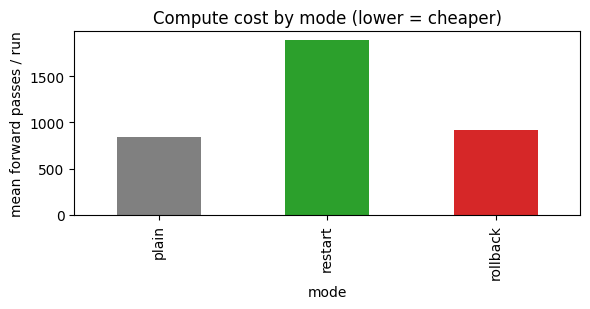

In [ ]:
import pandas as pd


def run_eval(
    modes=("plain", "rollback", "restart"),
    seeds=(0, 1),
    max_new_tokens=384,
    thresh=1.8,
    items=None,
):
    rows = []
    for item in items or MINIMAL_PAIRS:
        for variant in ("fixed", "buggy"):
            prompt = build_prompt(item, variant)
            for mode in modes:
                for seed in seeds:
                    r = prove(
                        prompt,
                        mode=mode,
                        max_new_tokens=max_new_tokens,
                        thresh=thresh,
                        seed=seed,
                    )
                    variant_data = item[variant]
                    # Narrow the inferred type for ty.
                    assert isinstance(variant_data, dict)
                    rows.append(
                        {
                            "id": item["id"],
                            "variant": variant,
                            "provable": variant_data["provable"],
                            "mode": mode,
                            "seed": seed,
                            "outcome": proxy_outcome(r["text"]),
                            "interventions": r["rollbacks"],
                            "gen_tokens": r["gen_tokens"],
                            "n_forward": r["n_forward"],
                            "prefills": r["n_prefills"],
                            "wall_s": r["wall_s"],
                        }
                    )
    return pd.DataFrame(rows)


# Lower the threshold below zero to guarantee interventions
df = run_eval(thresh=-1.0)
print(df.to_string(index=False))

print("\nOutcome by variant x mode:")
print(pd.crosstab([df.variant, df["mode"]], df.outcome))

print("\nCompute by mode:")
prompt_len = encode_prompt(build_prompt(MINIMAL_PAIRS[0], "buggy")).shape[1]
comp = (
    df.groupby("mode")
    .agg(
        interventions=("interventions", "mean"),
        fw_passes=("n_forward", "mean"),
        prefills=("prefills", "mean"),
        wall_s=("wall_s", "mean"),
    )
    .round(1)
)
comp["saved_vs_restart_fw"] = (
    comp.loc["restart", "fw_passes"] - comp["fw_passes"]
).round(0)
print(comp)

_, ax = plt.subplots(figsize=(6, 3.2))
comp["fw_passes"].plot.bar(ax=ax, color=["gray", "tab:green", "tab:red"])
ax.set_ylabel("mean forward passes / run")
ax.set_title("Compute cost by mode (lower = cheaper)")
plt.tight_layout()
plt.show()